### Démonstration interactive du Seam Carving

Ce notebook permet de :
- charger une image de test,
- calculer sa carte d’énergie (Sobel, gradient, etc.),
- appliquer plusieurs itérations de **Seam Carving vertical et horizontal**,
- observer la suppression des seams.




In [1]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from class_SeamCarver import SeamCarver

Image shape: (583, 860, 3)


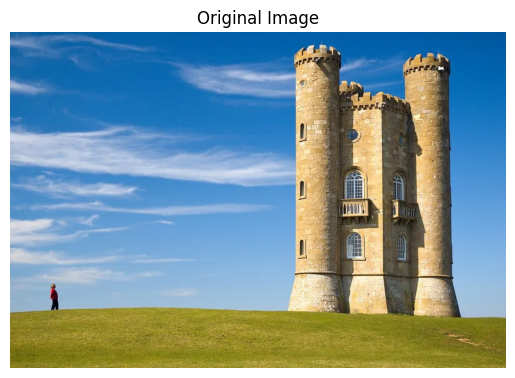

In [2]:
# 1) Load the image
image = cv2.imread('../dataset/broadway_original.webp')
print(f"Image shape: {image.shape}")

# 2) Display the image 
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

# 3) Create a SeamCarver object
sc = SeamCarver(image)

In [3]:
# 4) Define the number of seams to remove
num_seams = 450
# Note that the number of seams to remove should be less than the width of the image.

In [4]:
# 5) Perform seam carving (we use an optimal seam carving method wich removes seams based on energy minimization comparing horizontal and veertical seams)
# Note that the computation takes a while, so you can comment out the methods you don't want to use we already saved somes results in the dataset folder
carved_image_l1         = sc.optimal_seam_carve(num_seams, method='l1') 
carved_image_l2         = sc.optimal_seam_carve(num_seams, method='l2')
carved_image_HoG        = sc.optimal_seam_carve(num_seams, method='skimage_HOG')        # This method uses HOG features for seam carving with a fast algorithm using parallel implementation
carved_image_entropy    = sc.optimal_seam_carve(num_seams, method='skimage_entropy')    # This method uses skimage entropy for seam carving 
carved_image_saliency   = sc.optimal_seam_carve(num_seams, method='saliency')           # This method uses saliency map for seam carving 

Optimal seam carving with 450 seams removed in 443.56 seconds.
Optimal seam carving with 450 seams removed in 376.75 seconds.
Optimal seam carving with 450 seams removed in 496.43 seconds.
Optimal seam carving with 450 seams removed in 472.47 seconds.
Optimal seam carving with 450 seams removed in 393.05 seconds.


It can take a while to run (40 minutes on our computers for 400 seams)

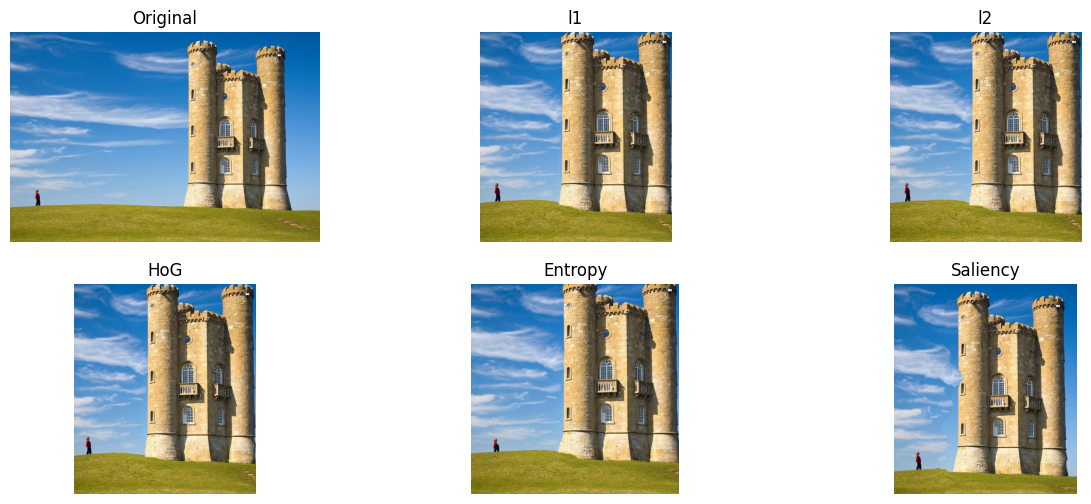

In [5]:
# 6) Display the original and all carved images in a simple way
images = [
    image,
    carved_image_l1.astype(np.uint8),
    carved_image_l2.astype(np.uint8),
    carved_image_HoG.astype(np.uint8),
    carved_image_entropy.astype(np.uint8),
    carved_image_saliency.astype(np.uint8),
]
titles = [
    'Original',
    'l1',
    'l2',
    'HoG',
    'Entropy',
    'Saliency'
]

plt.figure(figsize=(15, 6))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')
plt.show()

In [6]:
# 7) Save the carved images
cv2.imwrite('../dataset/broadway_l1.webp', carved_image_l1.astype(np.uint8))
cv2.imwrite('../dataset/broadway_l2.webp', carved_image_l2.astype(np.uint8))
cv2.imwrite('../dataset/broadway_HoG.webp', carved_image_HoG.astype(np.uint8))
cv2.imwrite('../dataset/broadway_entropy.webp', carved_image_entropy.astype(np.uint8))
cv2.imwrite('../dataset/broadway_saliency.webp', carved_image_saliency.astype(np.uint8))
# Note: The saliency method requires additional dependencies and may not be available in all environments.

True

In [7]:
from class_SeamCarver import compare_saliency_preservation

methods = {
    "l1": carved_image_l1,
    "l2": carved_image_l2,
    "HoG": carved_image_HoG,
    "entropy": carved_image_entropy,
    "saliency": carved_image_saliency
}

for method, img in methods.items():
    print(f"Saliency preservation for method: {method}")
    compare_saliency_preservation(image, {method: img})


Saliency preservation for method: l1
l1                        → preserved saliency score: 12603.25
Saliency preservation for method: l2
l2                        → preserved saliency score: 12621.91
Saliency preservation for method: HoG
HoG                       → preserved saliency score: 12594.09
Saliency preservation for method: entropy
entropy                   → preserved saliency score: 12577.57
Saliency preservation for method: saliency
saliency                  → preserved saliency score: 12270.40


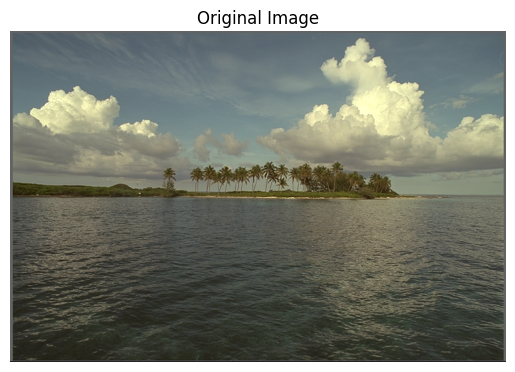

In [8]:
# 1) Load the image
image = cv2.imread('../dataset/kodim16.png')

# 2) Display the image 
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

# 3) Create a SeamCarver object
sc = SeamCarver(image)

In [9]:
# 4) Define the number of seams to remove
num_seams = 100

In [10]:
# 5) Perform seam carving (we use an optimal seam carving method wich removes seams based on energy minimization comparing horizontal and veertical seams)
carved_image_of_girl_l1         = sc.optimal_seam_carve(num_seams, method='l1') 
carved_image_of_girl_l2         = sc.optimal_seam_carve(num_seams, method='l2')
carved_image_of_girl_HoG        = sc.optimal_seam_carve(num_seams, method='skimage_HOG')# This method uses HOG features for seam carving with a fast algorithm using custom parallel implementation
carved_image_of_girl_entropy    = sc.optimal_seam_carve(num_seams, method='skimage_entropy') # This method uses skimage entropy for seam carving with a fast algorithm using custom parallel implementation
carved_image_of_girl_saliency   = sc.optimal_seam_carve(num_seams, method='saliency') # This method uses saliency map for seam carving with a fast algorithm using custom parallel implementation

Optimal seam carving with 100 seams removed in 84.95 seconds.
Optimal seam carving with 100 seams removed in 79.76 seconds.
Optimal seam carving with 100 seams removed in 104.31 seconds.
Optimal seam carving with 100 seams removed in 100.29 seconds.
Optimal seam carving with 100 seams removed in 80.80 seconds.


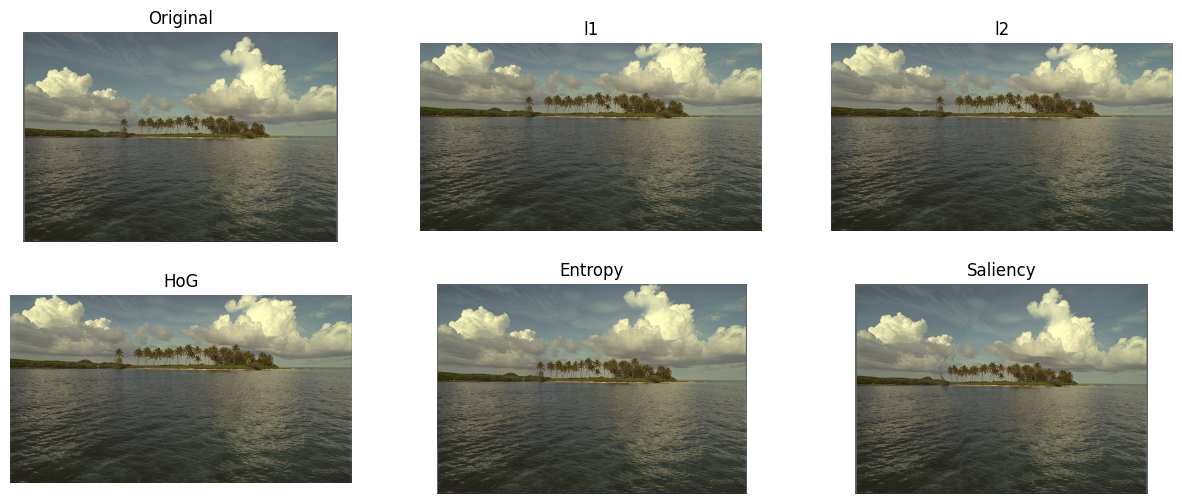

In [11]:
# 5) Display the original and all carved images in a simple way
images_of_girl = [
    image,
    carved_image_of_girl_l1.astype(np.uint8),
    carved_image_of_girl_l2.astype(np.uint8),
    carved_image_of_girl_HoG.astype(np.uint8),
    carved_image_of_girl_entropy.astype(np.uint8),
    carved_image_of_girl_saliency.astype(np.uint8)
]
titles = [
    'Original',
    'l1',
    'l2',
    'HoG',
    'Entropy',
    'Saliency'
]

plt.figure(figsize=(15, 6))
for i in range(len(images_of_girl)):
    plt.subplot(2, 3, i+1)
    plt.imshow(cv2.cvtColor(images_of_girl[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')
plt.show()

We observe bad results on faces only 

In [12]:
# 7) Save the carved images
cv2.imwrite('../dataset/carved_image_of_girl_l1.png', carved_image_of_girl_l1.astype(np.uint8))
cv2.imwrite('../dataset/carved_image_of_girl_l2.png', carved_image_of_girl_l2.astype(np.uint8))
cv2.imwrite('../dataset/carved_image_of_girl_HoG.png', carved_image_of_girl_HoG.astype(np.uint8))
cv2.imwrite('../dataset/carved_image_of_girl_entropy.png', carved_image_of_girl_entropy.astype(np.uint8))
cv2.imwrite('../dataset/carved_image_of_girl_saliency.png', carved_image_of_girl_saliency.astype(np.uint8))

True

In [13]:
methods = {
    "l1": carved_image_of_girl_l1,
    "l2": carved_image_of_girl_l2,
    "HoG": carved_image_of_girl_HoG,
    "entropy": carved_image_of_girl_entropy,
    "saliency": carved_image_of_girl_saliency
}

for method, img in methods.items():
    print(f"Saliency preservation for method: {method}")
    compare_saliency_preservation(image, {method: img})

Saliency preservation for method: l1
l1                        → preserved saliency score: 13802.10
Saliency preservation for method: l2
l2                        → preserved saliency score: 13796.67
Saliency preservation for method: HoG
HoG                       → preserved saliency score: 13843.78
Saliency preservation for method: entropy
entropy                   → preserved saliency score: 15626.89
Saliency preservation for method: saliency
saliency                  → preserved saliency score: 15756.60
